### Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

### 1. Upload Compliants Dataset

In [ ]:
file_path = "C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/raw/complaints.csv"
data = pd.read_csv(file_path)

C:\Users\pc\AppData\Local\Temp\ipykernel_16076\1113996730.py:2: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


In [ ]:
# Copy datasets to avoid modifying the original data
df = data.copy()

In [ ]:
# Display the shape of the DataFrame
df.shape

(9609797, 18)

In [ ]:
# Display the first few rows of the DataFrame
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


### 2.	Perform an initial EDA

#### Complaint Distribution Across Products 

In [ ]:
# Count the number of compliantes across products
product_counts = df["Product"].value_counts()

print("\nTop 10 Products by Complaint Count:")
print(product_counts.head(10))


Top 10 Products by Complaint Count:
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Name: count, dtype: int64


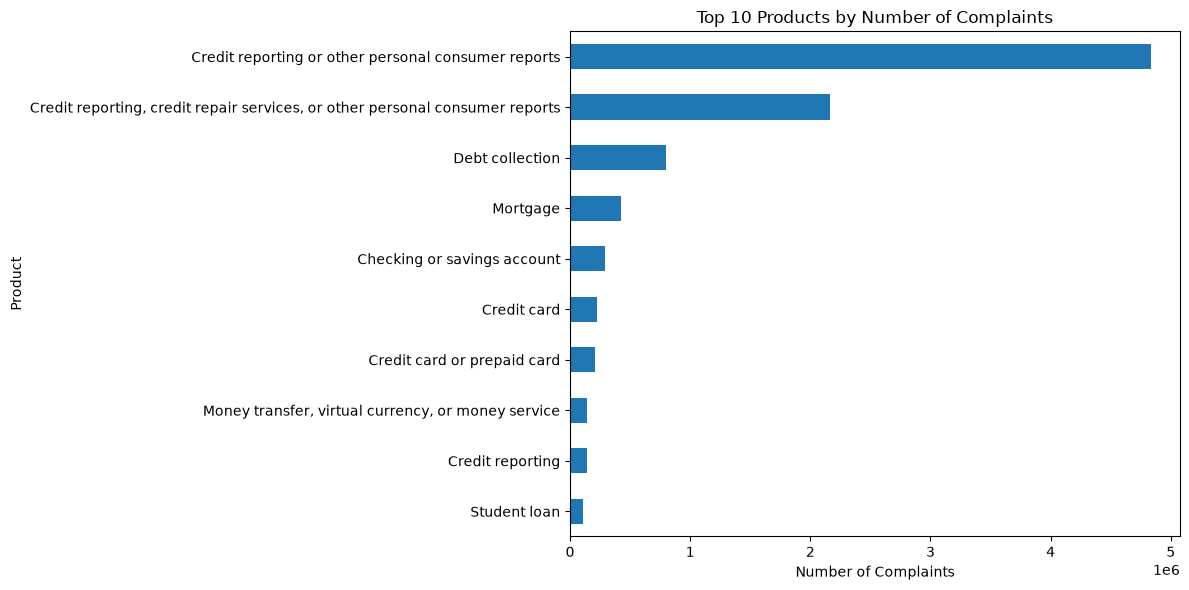

In [7]:
#Visualization 
plt.figure(figsize=(12, 6))
product_counts.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Products by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Complaints With and Without Narratives

In [8]:
narrative_col = "Consumer complaint narrative"

In [9]:

with_narrative = df[narrative_col].notna().sum()
without_narrative = df[narrative_col].isna().sum()

print("\nNarrative Availability")
print(f"Complaints with narratives    : {with_narrative:,}")
print(f"Complaints without narratives : {without_narrative:,}")


Narrative Availability
Complaints with narratives    : 2,980,756
Complaints without narratives : 6,629,041


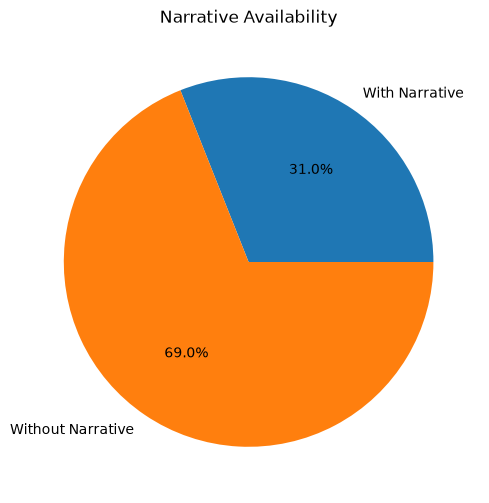

In [10]:
# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    [with_narrative, without_narrative],
    labels=["With Narrative", "Without Narrative"],
    autopct="%1.1f%%"
)
plt.title("Narrative Availability")
plt.show()

#### Calculate Narrative Word Counts

In [11]:
# Replace missing narratives with empty string
df[narrative_col] = df[narrative_col].fillna("")

# Word count
df["Narrative_Word_Count"] = (
    df[narrative_col]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# Summary statistics
print("\nNarrative Length Statistics")
print(df["Narrative_Word_Count"].describe())


Narrative Length Statistics
count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: Narrative_Word_Count, dtype: float64


#### Visualize Narrative Length Distribution

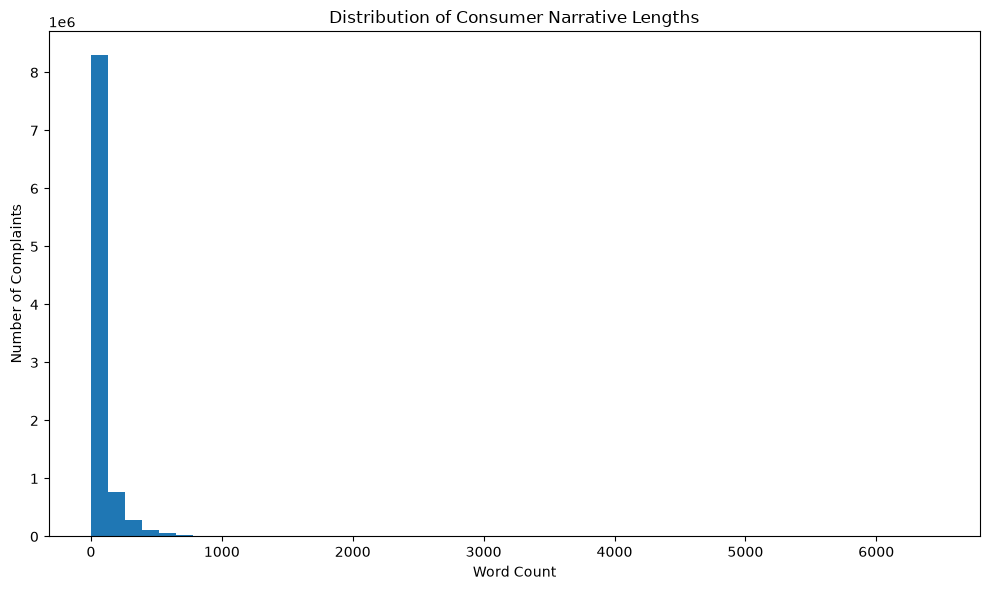

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(
    df["Narrative_Word_Count"],
    bins=50
)
plt.title("Distribution of Consumer Narrative Lengths")
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

#### Identify Very Short and Very Long Narratives

In [ ]:
# Thresholds (adjust as needed)
short_threshold = 10
long_threshold = 1000

very_short = df[df["Narrative_Word_Count"] < short_threshold]
very_long = df[df["Narrative_Word_Count"] > long_threshold]

print("\nNarrative Length Analysis")
print(f"Very short narratives (< {short_threshold} words): {len(very_short):,}")
print(f"Very long narratives (> {long_threshold} words): {len(very_long):,}")

#### Display Sample Narratives

In [ ]:
print("\nSample Very Short Narrative:")
if len(very_short) > 0:
    print(very_short[narrative_col].iloc[0])



Sample Very Short Narrative:



In [ ]:

print("\nSample Very Long Narrative (first 500 characters):")
if len(very_long) > 0:
    print(very_long[narrative_col].iloc[0][:500])


Sample Very Long Narrative (first 500 characters):
b'To Whom It May Concern,\n\nI am filing this complaint to formally address several inaccuracies and negative entries on my XXXX  credit report that I believe are either outdated, unverifiable, or incorrectly associated with my name and address.\n\nSpecifically, the report includes multiple negative accounts and derogatory remarks connected to variations of my name. These include:\n\nCharge-offs and collections that are not validated or properly documented\n\nLate payment histories that are inco


### Summary Table

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Complaints",
        "With Narratives",
        "Without Narratives",
        "Average Narrative Length",
        "Median Narrative Length",
        "Very Short Narratives",
        "Very Long Narratives"
    ],
    "Value": [
        len(df),
        with_narrative,
        without_narrative,
        round(df["Narrative_Word_Count"].mean(), 2),
        round(df["Narrative_Word_Count"].median(), 2),
        len(very_short),
        len(very_long)
    ]
})

print("\nSummary Report")
print(summary)


Summary Report
                     Metric       Value
0          Total Complaints  9609797.00
1           With Narratives  2980756.00
2        Without Narratives  6629041.00
3  Average Narrative Length       54.47
4   Median Narrative Length        0.00
5     Very Short Narratives  6650979.00
6      Very Long Narratives    32428.00


#### Filter the dataset

In [13]:
# Products to retain
target_products = [
    "Credit card or prepaid card",
    "Personal loan",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service"
]

# Filter records
filtered_df = df[df["Product"].isin(target_products)].copy()

In [14]:
# Remove records with missing or empty narratives
filtered_df = filtered_df[
    filtered_df[narrative_col].notna() &
    (filtered_df[narrative_col].str.strip() != "")
]

# Check results
print(f"Original dataset shape: {df.shape}")
print(f"Filtered dataset shape: {filtered_df.shape}")

print("\nProduct Distribution:")
print(filtered_df["Product"].value_counts())

print("\nMissing narratives remaining:")
print(filtered_df[narrative_col].isna().sum())

# Preview
print("\nFirst 5 records:")
print(filtered_df.head())

Original dataset shape: (9609797, 19)
Filtered dataset shape: (346174, 19)

Product Distribution:
Product
Checking or savings account                           140319
Credit card or prepaid card                           108667
Money transfer, virtual currency, or money service     97188
Name: count, dtype: int64

Missing narratives remaining:
0

First 5 records:
      Date received                                            Product  \
12532    2025-06-13                        Checking or savings account   
14562    2025-06-08                        Checking or savings account   
17030    2025-06-09                        Checking or savings account   
17118    2025-06-09  Money transfer, virtual currency, or money ser...   
21658    2025-05-30                        Checking or savings account   

                    Sub-product                                   Issue  \
12532          Checking account                     Managing an account   
14562          Checking account        

#### Clean the text narratives

In [15]:
BOILERPLATE_PATTERNS = [
    r"i am writing to file a complaint",
    r"i would like to file a complaint",
    r"consumer complaint narrative",
    r"this complaint is about",
    r"i am submitting this complaint",
    r"i am filing this complaint",
    r"please investigate",
]

In [16]:
def clean_text(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove boilerplate phrases
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
filtered_df["cleaned_narrative"] = filtered_df[narrative_col].apply(clean_text)

# -----------------------------------------------------
# Compare original vs cleaned
# -----------------------------------------------------
print("Original Narrative:")
print(filtered_df[narrative_col].iloc[0][:300])

print("\nCleaned Narrative:")
print(filtered_df["cleaned_narrative"].iloc[0][:300])

Original Narrative:
I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the customer service for help. I did this and was told I was helped gave all the info for the time terminal i

Cleaned Narrative:
i made the mistake of using my wellsfargo debit card to depsit funds into xxxxxxxx atm machine outside their branch i went into the branch and was told they couldn t help and had to phone the customer service for help i did this and was told i was helped gave all the info for the time terminal id aa


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

filtered_df["normalized_narrative"] = (
    filtered_df["cleaned_narrative"]
    .apply(normalize_text)
)

print(filtered_df["normalized_narrative"].head())

In [21]:
# Save filtered and cleaned dataset
file_path = "C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/processed/filtered_complaints.csv"
filtered_df.to_csv(file_path, index=False)

print("\nFiltered complaints data saved successfully.")


Filtered complaints data saved successfully.


### 3. Text Chunking, Embedding, and Vector Store Indexing

In [2]:
file_path = "C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/processed/filtered_complaints.csv"
clean_df = pd.read_csv(file_path)

In [3]:
clean_df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,Narrative_Word_Count,cleaned_narrative
0,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,109,i made the mistake of using my wellsfargo debi...
1,2025-06-08,Checking or savings account,Checking account,Managing an account,Problem accessing account,Got locked out of my account because I was try...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",MI,49401,Servicemember,Consent provided,Web,2025-06-08,Closed with explanation,Yes,NaN,13960106,235,got locked out of my account because i was try...
2,2025-06-09,Checking or savings account,Checking account,Problem caused by your funds being low,Overdrafts and overdraft fees,I am in the process of applying for a mortgage...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,TX,77047,NaN,Consent provided,Web,2025-06-09,Closed with explanation,Yes,NaN,13976941,57,i am in the process of applying for a mortgage...
3,2025-06-09,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Fraud or scam,NaN,This all happened in XXXX and XXXX was taken f...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,TX,75602,Servicemember,Consent provided,Web,2025-06-09,Closed with explanation,Yes,NaN,13974625,510,this all happened in xxxx and xxxx was taken f...
4,2025-05-30,Checking or savings account,Savings account,Closing an account,Company closed your account,USAA SAVINGS BANK DECIDED TO CLOSE MY ACCOUNT ...,Company has responded to the consumer and the ...,UNITED SERVICES AUTOMOBILE ASSOCIATION,TX,XXXXX,Servicemember,Consent provided,Web,2025-05-30,Closed with explanation,Yes,NaN,13810547,64,usaa savings bank decided to close my account ...


In [5]:
clean_df.shape

(346174, 20)

#### Stratified sample of complaints 

In [4]:
# Product column
PRODUCT_COL = "Product"

# Check Product Distribution
print("Original Product Distribution:")
print(clean_df[PRODUCT_COL].value_counts())

print("\nOriginal Product Percentages:")
print(clean_df[PRODUCT_COL].value_counts(normalize=True) * 100)

Original Product Distribution:
Product
Checking or savings account                           140319
Credit card or prepaid card                           108667
Money transfer, virtual currency, or money service     97188
Name: count, dtype: int64

Original Product Percentages:
Product
Checking or savings account                           40.534240
Credit card or prepaid card                           31.390861
Money transfer, virtual currency, or money service    28.074899
Name: proportion, dtype: float64


In [5]:
# Define Sample Size
sample_size = 12000  # Choose between 10,000 and 15,000

sample_df, _ = train_test_split(
    clean_df,
    train_size=sample_size,
    stratify=clean_df[PRODUCT_COL],
    random_state=42
)

In [6]:
# Verify Sample Distribution
print("\nSample Shape:")
print(sample_df.shape)

print("\nSample Product Distribution:")
print(sample_df[PRODUCT_COL].value_counts())

print("\nSample Product Percentages:")
print(
    round(
        sample_df[PRODUCT_COL]
        .value_counts(normalize=True) * 100,
        2
    )
)


Sample Shape:
(12000, 20)

Sample Product Distribution:
Product
Checking or savings account                           4864
Credit card or prepaid card                           3767
Money transfer, virtual currency, or money service    3369
Name: count, dtype: int64

Sample Product Percentages:
Product
Checking or savings account                           40.53
Credit card or prepaid card                           31.39
Money transfer, virtual currency, or money service    28.08
Name: proportion, dtype: float64


In [7]:
# Compare Original vs Sample Distribution
comparison = pd.DataFrame({
    "Original_Count": clean_df[PRODUCT_COL].value_counts(),
    "Original_%": round(
        clean_df[PRODUCT_COL].value_counts(normalize=True) * 100, 2
    ),
    "Sample_Count": sample_df[PRODUCT_COL].value_counts(),
    "Sample_%": round(
        sample_df[PRODUCT_COL].value_counts(normalize=True) * 100, 2
    )
})

print("\nDistribution Comparison")
print(comparison)


Distribution Comparison
                                                    Original_Count  \
Product                                                              
Checking or savings account                                 140319   
Credit card or prepaid card                                 108667   
Money transfer, virtual currency, or money service           97188   

                                                    Original_%  Sample_Count  \
Product                                                                        
Checking or savings account                              40.53          4864   
Credit card or prepaid card                              31.39          3767   
Money transfer, virtual currency, or money service       28.07          3369   

                                                    Sample_%  
Product                                                       
Checking or savings account                            40.53  
Credit card or prepaid card       

#### Implement a text chunking strategy

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [11]:
clean_df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID',
       'Narrative_Word_Count', 'cleaned_narrative'],
      dtype='str')

In [9]:

TEXT_COL = "cleaned_narrative"

In [10]:
# Configure Text Splitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", " ", ""]
)

In [11]:
# Generate Chunks
chunked_records = []

for idx, row in clean_df.iterrows():

    text = str(row[TEXT_COL])

    chunks = splitter.split_text(text)

    for chunk_id, chunk in enumerate(chunks):

        chunked_records.append({
            "original_index": idx,
            "product": row["Product"],
            "chunk_id": chunk_id,
            "chunk_text": chunk,
            "chunk_length": len(chunk)
        })

In [12]:
# Create chunk dataframe
chunks_df = pd.DataFrame(chunked_records)

print("Number of Original Complaints:", len(clean_df))
print("Number of Chunks:", len(chunks_df))

print(chunks_df.head())

Number of Original Complaints: 346174
Number of Chunks: 1049457
   original_index                      product  chunk_id  \
0               0  Checking or savings account         0   
1               0  Checking or savings account         1   
2               1  Checking or savings account         0   
3               1  Checking or savings account         1   
4               1  Checking or savings account         2   

                                          chunk_text  chunk_length  
0  i made the mistake of using my wellsfargo debi...           497  
1  few days i waited a few days and got a letter ...           144  
2  got locked out of my account because i was try...           498  
3  my secret word which i have no recollection of...           498  
4  this day and requested for a status for when i...           418  


In [13]:
sample_text = clean_df["cleaned_narrative"].iloc[0]

configs = [
    (300, 50),
    (500, 100),
    (800, 150),
    (1000, 200)
]

for chunk_size, overlap in configs:

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap
    )

    chunks = splitter.split_text(sample_text)

    print(f"\nChunk Size: {chunk_size}")
    print(f"Overlap: {overlap}")
    print(f"Number of Chunks: {len(chunks)}")

    if len(chunks) > 0:
        print(f"Average Chunk Length: "
              f"{sum(len(c) for c in chunks)/len(chunks):.2f}")


Chunk Size: 300
Overlap: 50
Number of Chunks: 2
Average Chunk Length: 295.50

Chunk Size: 500
Overlap: 100
Number of Chunks: 2
Average Chunk Length: 320.50

Chunk Size: 800
Overlap: 150
Number of Chunks: 1
Average Chunk Length: 542.00

Chunk Size: 1000
Overlap: 200
Number of Chunks: 1
Average Chunk Length: 542.00


In [14]:
def chunk_text(text, chunk_size=500, overlap=100):

    chunks = []

    start = 0

    while start < len(text):

        end = start + chunk_size

        chunks.append(text[start:end])

        start += chunk_size - overlap

    return chunks


# Example
sample_text = clean_df["cleaned_narrative"].iloc[0]

chunks = chunk_text(
    sample_text,
    chunk_size=500,
    overlap=100
)

print("Number of Chunks:", len(chunks))
print(chunks[0][:200])

Number of Chunks: 2
i made the mistake of using my wellsfargo debit card to depsit funds into xxxxxxxx atm machine outside their branch i went into the branch and was told they couldn t help and had to phone the customer


In [15]:
print("\nChunk Length Statistics")
print(chunks_df["chunk_length"].describe())

print("\nAverage Chunks per Complaint")
print(
    chunks_df.groupby("original_index")
             .size()
             .mean()
)


Chunk Length Statistics
count    1.049457e+06
mean     4.270897e+02
std      1.193228e+02
min      4.000000e+00
25%      3.850000e+02
50%      4.950000e+02
75%      4.980000e+02
max      5.000000e+02
Name: chunk_length, dtype: float64

Average Chunks per Complaint
3.0315881608670785


In [20]:
# Save
chunks_df.to_csv("C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/complaint_chunks.csv", index=False)

#### Choose an embedding model.

In [16]:
import chromadb
from sentence_transformers import SentenceTransformer

In [17]:
print("Loading chunked dataset...")

chunks_df = pd.read_csv("C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/complaint_chunks.csv")

print(f"Number of chunks: {len(chunks_df):,}")

print(chunks_df.head())

Loading chunked dataset...
Number of chunks: 1,049,457
   original_index                      product  chunk_id  \
0               0  Checking or savings account         0   
1               0  Checking or savings account         1   
2               1  Checking or savings account         0   
3               1  Checking or savings account         1   
4               1  Checking or savings account         2   

                                          chunk_text  chunk_length  
0  i made the mistake of using my wellsfargo debi...           497  
1  few days i waited a few days and got a letter ...           144  
2  got locked out of my account because i was try...           498  
3  my secret word which i have no recollection of...           498  
4  this day and requested for a status for when i...           418  


In [22]:
chunks_df.columns

Index(['original_index', 'product', 'chunk_id', 'chunk_text', 'chunk_length'], dtype='str')

In [23]:
required_columns = [
    "original_index",
    "product",
    "chunk_id",
    "chunk_text"
]

missing_cols = [
    col for col in required_columns
    if col not in chunks_df.columns
]

if missing_cols:
    raise ValueError(
        f"Missing columns: {missing_cols}"
    )

In [24]:
# Load model
print("Loading embedding model...")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully.")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully.


In [ ]:
print("Generating embeddings...")

texts = chunks_df['chunk_text'].astype(str).tolist()

embeddings = embedding_model.encode(
    texts,
    batch_size=2564,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding Shape:", embeddings.shape)


Generating embeddings...


Batches:   0%|          | 0/410 [00:00<?, ?it/s]

In [ ]:
texts = chunks_df["chunk_text"].tolist()

# Create embeddings
embeddings = embedding_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

print("Number of chunks:", embeddings.shape[0])
print("Embedding dimension:", embeddings.shape[1])

Batches:   0%|          | 0/16398 [00:00<?, ?it/s]

In [ ]:
# add embedding to dataframe
chunks_df["embedding"] = embeddings.tolist()

print(chunks_df.head())

In [ ]:
# Save embeddings
np.save("complaint_embeddings.npy", embeddings)

print("Embeddings saved successfully.")

#### Create a vector store using FAISS 

In [ ]:
import faiss
import pickle

In [ ]:
# Load chunk dataset
chunks_df = pd.read_csv("complaint_chunks.csv")

# Load embeddings
embeddings = np.load("complaint_embeddings.npy")

# Convert to float32 (required by FAISS)
embeddings = embeddings.astype("float32")

In [ ]:
# Build FAISS Index
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Number of vectors stored:", index.ntotal)

In [ ]:
# Store Metadata Separately
metadata = []

for _, row in chunks_df.iterrows():

    metadata.append({
        "complaint_id": row["original_index"],
        "product": row["product"],
        "chunk_id": row["chunk_id"],
        "chunk_text": row["chunk_text"]
    })

In [ ]:
# Save metadata
with open("faiss_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

In [ ]:
# Save FAISS index
faiss.write_index(index, "complaint_faiss.index")

print("FAISS index and metadata saved.")

#### Semantic Search

In [ ]:
# Load model
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Load index
index = faiss.read_index("complaint_faiss.index")

# Load metadata
with open("faiss_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

# Query
query = "unauthorized charges on my credit card"

query_embedding = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

# Retrieve top-k matches
k = 5

distances, indices = index.search(
    query_embedding,
    k
)

# Display Results
for rank, idx in enumerate(indices[0], start=1):

    result = metadata[idx]

    print(f"\nRank {rank}")
    print(f"Complaint ID: {result['complaint_id']}")
    print(f"Product: {result['product']}")
    print(f"Chunk ID: {result['chunk_id']}")
    print(result["chunk_text"][:300])

#### FAISS

In [ ]:
import pandas as pd
import numpy as np
import faiss
import json

In [ ]:
# 1. Load the Parquet file
print("Loading Parquet file...")
df = pd.read_parquet('C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/data/raw/complaint_embeddings-002.parquet')

#### Create a vector store using chromadb 

In [ ]:
import chromadb

In [ ]:
# Load Chunked Dataset
chunks_df = pd.read_csv("complaint_chunks.csv")

print(f"Number of chunks: {len(chunks_df):,}")

In [ ]:
# Load Embedding Model
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [ ]:
client = chromadb.PersistentClient(
    path="C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/vector_store"
)

collection = client.get_or_create_collection(
    name="complaints"
)

In [ ]:
# Generate Embeddings and Store
batch_size = 256

for start in range(0, len(chunks_df), batch_size):

    end = min(start + batch_size, len(chunks_df))

    batch = chunks_df.iloc[start:end]

    documents = batch["chunk_text"].astype(str).tolist()

    embeddings = model.encode(
        documents,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    ids = [
        f"chunk_{i}"
        for i in range(start, end)
    ]

    metadatas = []

    for _, row in batch.iterrows():

        metadatas.append({
            "complaint_id": str(row["original_index"]),
            "product": str(row["product"]),
            "chunk_id": int(row["chunk_id"])
        })

    collection.add(
        ids=ids,
        documents=documents,
        embeddings=embeddings.tolist(),
        metadatas=metadatas
    )

    print(f"Stored records {start:,} - {end:,}")

print("\nVector store saved successfully.")
print("Location: vector_store/")

In [ ]:
# Load Existing Vector Store
import chromadb

client = chromadb.PersistentClient(
    path="C:/Users/pc/Desktop/week 7/RAG_complaint_chatbot/vector_store"
)

collection = client.get_collection(
    name="complaints"
)

print("Documents stored:",
      collection.count())

#### Semantic Search Test

In [ ]:

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

query = "unauthorized credit card transaction"

query_embedding = model.encode(
    query
).tolist()

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=5
)

for i in range(len(results["documents"][0])):

    print(f"\nResult {i+1}")

    print("Metadata:")
    print(results["metadatas"][0][i])

    print("\nText:")
    print(results["documents"][0][i][:300])